# 12 - 全量信号 + 综合评分仪表盘

对 core 池股票生成跨类别信号（技术/基本面/资金流/情绪），加权汇总为综合评分，
并以仪表盘形式展示。

**本 Notebook 包含：**
1. 评分体系说明（各分数的含义）
2. 当日综合评分排名
3. 单票信号拆解
4. 评分时序趋势（近 N 天 composite 变化）
5. 写入数据库

**前置：** 数据采集已完成，DDL 已建好

## 评分体系说明

| 维度 | 权重 | 包含信号 | 含义 |
|------|------|----------|------|
| **tech_score** (技术面) | 35% | MACD/RSI/布林/MA偏离/量比/动量/波动率 | 价格趋势和动量强弱 |
| **fund_score** (基本面) | 30% | PE分位/PB分位/ROE/营收增速/负债率 | 估值和盈利质量 |
| **flow_score** (资金流) | 20% | 主力净流入/超大单占比/融资余额变化 | 聪明钱方向 |
| **sent_score** (情绪面) | 15% | 换手率极值/股东户数变化/大股东增减持 | 市场情绪和筹码结构 |

**composite** = 四类子分的加权平均，取值 [-1, +1]：
- \> +0.3: 强烈看多
- +0.1 ~ +0.3: 偏多
- -0.1 ~ +0.1: 中性
- -0.3 ~ -0.1: 偏空
- < -0.3: 强烈看空

**rank_pct**: 当日在全池中的分位排名，1.0 = 最强，0.0 = 最弱

## 1. 初始化

In [25]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager
import os
from datetime import datetime
from IPython.display import display, HTML

# 解决 matplotlib 中文乱码：删除旧缓存，强制重建，使用 Noto Sans CJK
_cache_dir = matplotlib.get_cachedir()
for _f in os.listdir(_cache_dir):
    if _f.startswith('fontlist'):
        os.remove(os.path.join(_cache_dir, _f))
from matplotlib.font_manager import FontManager as _FM
_fm = _FM()
fontManager.__dict__.update(_fm.__dict__)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Noto Sans CJK SC', 'Droid Sans Fallback'] + plt.rcParams['font.sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

from invest_model.db import get_engine
from invest_model.repositories.stock_pool_repo import StockPoolRepository
from invest_model.repositories.stock_daily_repo import StockDailyRepository
from invest_model.repositories.signal_repo import SignalRepository
from invest_model.repositories.base import BaseRepository
from invest_model.scoring import CompositeScorer, save_signal_snapshots, save_composite_scores

engine = get_engine()
pool_repo = StockPoolRepository(engine)
daily_repo = StockDailyRepository(engine)
signal_repo = SignalRepository(engine)
base_repo = BaseRepository(engine)

core_codes = pool_repo.get_pool_codes('core')
_pool_df = pool_repo.get_pool('core')
code_name_map = dict(zip(_pool_df['code'], _pool_df['name']))

latest_dates = [d for d in (daily_repo.get_latest_date(code=c) for c in core_codes) if d]
trade_date = max(latest_dates)
print(f'core 池 {len(core_codes)} 只, 打分日: {trade_date}')


core 池 5 只, 打分日: 20260429


## 2. 生成当日综合评分

In [26]:
scorer = CompositeScorer(engine)
score_df, snapshots = scorer.score_batch(core_codes, trade_date)
score_df.insert(1, 'name', score_df['code'].map(code_name_map))
print(f'评分完成: {len(score_df)} 只\n')

# 按综合分排序展示
ranking = score_df.sort_values('composite', ascending=False)[
    ['code', 'name', 'composite', 'rank_pct', 'tech_score', 'fund_score', 'flow_score', 'sent_score']
].reset_index(drop=True)
ranking.index += 1
ranking.index.name = '#'
display(ranking)

评分完成: 5 只



,code,name,composite,rank_pct,tech_score,fund_score,flow_score,sent_score
#,,,,,,,,
1,600691.SH,潞化科技,0.007137,1.0,-0.101037,0.000000,0.000000,0.283333
2,000833.SZ,粤桂股份,-0.020952,0.8,-0.048434,0.053333,0.000000,-0.133333
3,002648.SZ,卫星化学,-0.025719,0.6,-0.218947,0.194709,0.100000,-0.183333
4,300442.SZ,润泽科技,-0.049450,0.4,-0.193834,0.027972,0.000000,0.066667
5,002594.SZ,比亚迪,-0.102863,0.2,-0.198657,-0.266667,0.233333,0.000000


## 3. 单票信号拆解

选综合评分最高的一只，展示其 18 个信号的逐项打分和人类可读标签。

In [27]:
if snapshots:
    top_code = score_df.sort_values('composite', ascending=False).iloc[0]['code']
    top_name = code_name_map.get(top_code, '')
    snap = snapshots[top_code]

    print(f'=== {top_code} {top_name} | composite = {snap.composite_score:+.3f} ===\n')

    rows = []
    for s in snap.signals:
        rows.append({
            'category': s.name.split('_')[0] if '_' in s.name else 'tech',
            'signal': s.name,
            'score': f'{s.score:+.3f}',
            'direction': s.direction.value,
            'strength': s.strength.value,
            'label': s.label,
        })
    detail = pd.DataFrame(rows)
    display(detail)

    # 归因摘要
    from invest_model.scoring import narrative
    print(f'\n归因: {narrative(snap)}')

=== 600691.SH 潞化科技 | composite = +0.007 ===



,category,signal,score,direction,strength,label
0,pe,pe_rank,+0.000,neutral,weak,pe_rank 截面数据缺失
1,pb,pb_rank,+0.000,neutral,weak,pb_rank 截面数据缺失
2,roe,roe_level,+0.000,neutral,weak,roe_level 截面数据缺失
3,revenue,revenue_growth,+0.000,neutral,weak,revenue_growth 截面数据缺失
4,debt,debt_level,+0.000,neutral,weak,debt_level 截面数据缺失
5,main,main_inflow_5d,+0.000,neutral,weak,主力 5 日净流入 -3.3 万手 (流通占比 -0.04)
6,elg,elg_ratio,+0.000,neutral,weak,超大单资金基本平衡 (-0.50%)
7,margin,margin_delta_5d,+0.000,neutral,weak,缺少融资数据
8,turnover,turnover_extreme,+0.150,bullish,weak,换手率健康 (327.90%)
9,holder,holder_count_trend,+0.700,bullish,strong,股东户数较上期增加 49.06%，筹码分散



归因: 多空相当（综合 +0.01）。看多：股东户数较上期增加 49.06%，筹码分散、MACD 金叉，趋势转多；看空：价格接近布林上轨 (100%)，波动加大、20日年化波动率极高 (51.91%)，风险显著。


## 4. 评分时序趋势

查看每只股票近 30 个交易日的 composite 变化，观察多空趋势是否在加强/减弱。

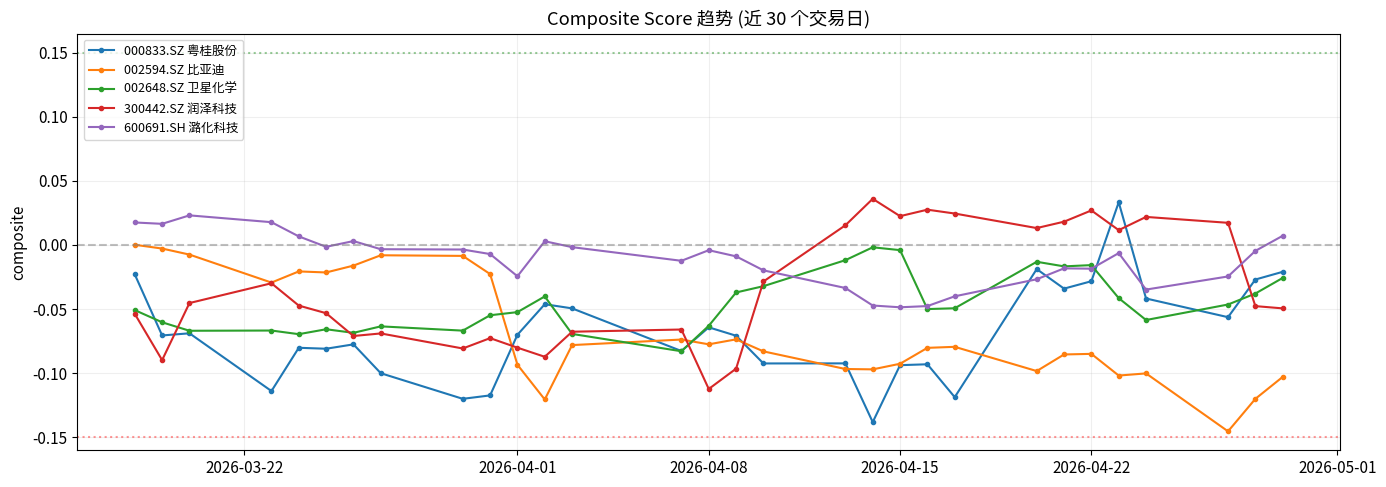


== 趋势变化 ==
  000833.SZ 粤桂股份     近5日均值=-0.023  变化=+0.036 >>
  002594.SZ 比亚迪      近5日均值=-0.114  变化=-0.028 <<
  002648.SZ 卫星化学     近5日均值=-0.042  变化=-0.013 <
  300442.SZ 润泽科技     近5日均值=-0.009  变化=-0.031 <<
  600691.SH 潞化科技     近5日均值=-0.013  变化=+0.018 >


In [28]:
TREND_DAYS = 30

# 从 DB 拉时序数据
from invest_model.repositories.calendar_repo import CalendarRepository
cal = CalendarRepository(engine)
all_dates = cal.get_trade_dates('20200101', trade_date)
start_idx = max(0, len(all_dates) - TREND_DAYS)
trend_start = all_dates[start_idx]

trend_data = signal_repo.get_score_series(core_codes, trend_start, trade_date)

if trend_data.empty:
    print('[!] 无历史评分数据, 请先运行回灌或 daily_pipeline')
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    for code in core_codes:
        sub = trend_data[trend_data['code'] == code].copy()
        if sub.empty:
            continue
        sub['date'] = pd.to_datetime(sub['trade_date'], format='%Y%m%d')
        sub = sub.sort_values('date')
        label = f'{code} {code_name_map.get(code, "")}'
        ax.plot(sub['date'], sub['composite'], linewidth=1.5, label=label, marker='o', markersize=3)

    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(0.15, color='green', linestyle=':', alpha=0.4)
    ax.axhline(-0.15, color='red', linestyle=':', alpha=0.4)
    ax.set_title(f'Composite Score 趋势 (近 {TREND_DAYS} 个交易日)')
    ax.set_ylabel('composite')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    # 趋势变化描述
    print('\n== 趋势变化 ==')
    for code in core_codes:
        sub = trend_data[trend_data['code'] == code].sort_values('trade_date')
        if len(sub) < 5:
            continue
        recent_5 = sub.tail(5)['composite'].mean()
        prev_5 = sub.iloc[-10:-5]['composite'].mean() if len(sub) >= 10 else sub.head(5)['composite'].mean()
        delta = recent_5 - prev_5
        arrow = '>>>' if delta > 0.05 else '>>' if delta > 0.02 else '>' if delta > 0 else '<' if delta > -0.02 else '<<' if delta > -0.05 else '<<<'
        print(f'  {code} {code_name_map.get(code, ""):8s} '
              f'近5日均值={recent_5:+.3f}  变化={delta:+.3f} {arrow}')

## 5. 写入数据库

In [29]:
n_sigs = save_signal_snapshots(engine, snapshots)
n_comp = save_composite_scores(engine, score_df)
print(f'signal_snapshot: {n_sigs} 条, composite_score: {n_comp} 条')

signal_snapshot: 90 条, composite_score: 5 条


## 6. 全池摘要（完整归因）

展示每只股票的完整归因文字，不截断。

In [30]:
result_df = signal_repo.get_composite_cross_section(trade_date)
if result_df.empty:
    print('无数据')
else:
    result_df.insert(1, 'name', result_df['code'].map(code_name_map))
    display(result_df[['code', 'name', 'composite', 'rank_pct',
                       'tech_score', 'fund_score', 'flow_score', 'sent_score']])
    print('\n== 各股归因摘要 ==')
    for _, row in result_df.iterrows():
        print(f'\n[{row["code"]} {row["name"]}] composite={row["composite"]:+.4f}')
        print(f'  {row["summary"]}')

,code,name,composite,rank_pct,tech_score,fund_score,flow_score,sent_score
0,600691.SH,潞化科技,0.007137,1.0,-0.101037,0.000000,0.000000,0.283333
1,000833.SZ,粤桂股份,-0.020952,0.8,-0.048434,0.053333,0.000000,-0.133333
2,002648.SZ,卫星化学,-0.025719,0.6,-0.218947,0.194709,0.100000,-0.183333
3,300442.SZ,润泽科技,-0.049450,0.4,-0.193834,0.027972,0.000000,0.066667
4,002594.SZ,比亚迪,-0.102863,0.2,-0.198657,-0.266667,0.233333,0.000000



== 各股归因摘要 ==

[600691.SH 潞化科技] composite=+0.0071
  多空相当（综合 +0.01）。看多：股东户数较上期增加 49.06%，筹码分散、MACD 金叉，趋势转多；看空：价格接近布林上轨 (100%)，波动加大、20日年化波动率极高 (51.91%)，风险显著。

[000833.SZ 粤桂股份] composite=-0.0210
  多空相当（综合 -0.02）。看多：MACD 多头强势，趋势向上、PE 处于行业低位 (分位 20%，PE=40.0)；看空：价格接近布林上轨 (100%)，波动加大、MA60 大幅偏离上方 (18.57%)，均值回归概率增大。

[002648.SZ 卫星化学] composite=-0.0257
  多空相当（综合 -0.03）。看多：PE 处于行业低位 (分位 2%，PE=16.8)、超大单资金基本平衡 (1.02%)；看空：价格接近布林上轨 (100%)，波动加大、股东户数较上期下降 15.12%，筹码明显集中。

[300442.SZ 润泽科技] composite=-0.0495
  多空相当（综合 -0.05）。看多：PE 处于行业低位 (分位 3%，PE=28.4)、20日动量偏多 (11.93%)；看空：PB 处于行业高位 (分位 90%，PB=10.35)、价格接近布林上轨 (100%)，波动加大。

[002594.SZ 比亚迪] composite=-0.1029
  整体偏空（综合 -0.10）。看多：超大单净流入占比 3.13%，主力买盘积极、股东户数较上期增加 6.96%，筹码分散；看空：价格接近布林上轨 (100%)，波动加大、PB 处于行业高位 (分位 87%，PB=4.14)。
